In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Datasets
movies=pd.read_csv("movies.csv")
ratings=pd.read_csv("ratings.csv")
tags=pd.read_csv("tags.csv")

In [14]:
movies.columns=[str(col).strip().lower().replace('_','')for col in movies.columns]
ratings.columns=[str(col).strip().lower().replace('_','')for col in ratings.columns]
tags.columns=[str(col).strip().lower().replace('_','')for col in tags.columns]

In [15]:
print(movies.columns)
print(ratings.columns)
print(tags.columns)

Index(['movieid', 'title', 'genres'], dtype='str')
Index(['userid', 'movieid', 'rating', 'timestamp'], dtype='str')
Index(['userid', 'movieid', 'tag', 'timestamp'], dtype='str')


In [20]:
# Merge datasets
df=pd.merge(movies, ratings, on="movieid")

In [21]:
# Basic Info
print(df.head())
print(df.info())

   movieid             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userid  rating   timestamp  
0       3     4.0   944919407  
1       6     5.0   858275452  
2       8     4.0   833981871  
3      10     4.0   943497887  
4      11     4.5  1230858821  
<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieid    int64  
 1   title      str    
 2   genres     str    
 3   userid     int64  
 4   rating     float64
 5   timestamp  int64  
dtypes: float64(1), int64(3), str(2)
memory usage:

In [22]:
# Handle missing values
df=df.dropna()

In [24]:
# Average Rating per movie
avg_rating=df.groupby('title')['rating'].mean().sort_values(ascending=False)
print("Top Rated Movies:\n",avg_rating.head())


Top Rated Movies:
 title
Sierra, La (2005)                                         5.0
A Night for Dying Tigers (2010)                           5.0
Hollywood and The Pentagon: A Dangerous Liaison (2003)    5.0
When I Walk (2013)                                        5.0
A Gun for Jennifer (1997)                                 5.0
Name: rating, dtype: float64


In [32]:
# Most Popular movies (based on count)
popular=df.groupby('title')['rating'].count().sort_values(ascending=False)
print("Most Popular Movies:\n",popular.head())


Most Popular Movies:
 title
Pulp Fiction (1994)                 67310
Forrest Gump (1994)                 66172
Shawshank Redemption, The (1994)    63366
Silence of the Lambs, The (1991)    63299
Jurassic Park (1993)                59715
Name: rating, dtype: int64


In [34]:
# Genre analysis
genre_rating=df.groupby('genres')['rating'].mean().sort_values(ascending=False)
print("Top Genre:\n",genre_rating.head())

Top Genre:
 genres
Adventure|Children|Comedy|Documentary|Drama    5.0
Adventure|Children|Mystery                     5.0
Adventure|Drama|Fantasy|Musical                5.0
Children|Drama|Thriller                        4.5
Comedy|Crime|Film-Noir                         4.5
Name: rating, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

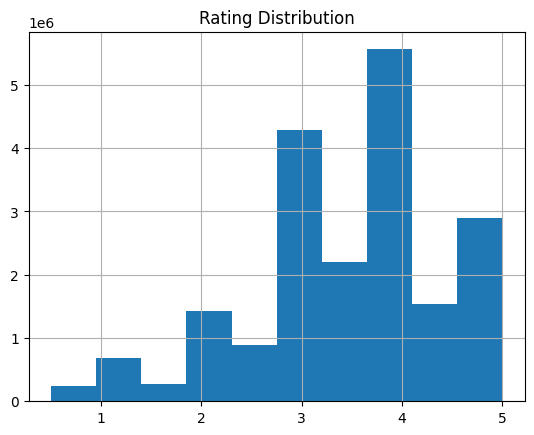

In [35]:
# Visualization-Rating distribution
plt.Figure()
df['rating'].hist()
plt.title("Rating Distribution")
plt.show

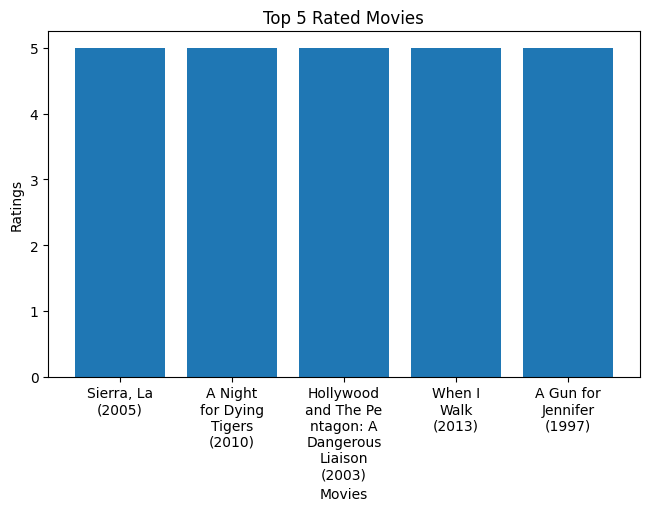

In [50]:
import textwrap
# Visualization-Top 5 Rated Movies
labels=[textwrap.fill(label,10)for label in avg_rating.head().index]
plt.Figure()
plt.bar(labels,avg_rating.head().values)
plt.xticks(rotation=0)
plt.tight_layout()
plt.title("Top 5 Rated Movies")
plt.xlabel("Movies")
plt.ylabel("Ratings")
plt.show()

In [49]:
# Insights
# 1. Some movies have very high ratings
# 2. Popular movies have more reviews
# 3. certain genre perform better